In [4]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA GeForce RTX 2050


# LipiLens V1 - Dataset Exploration

The goal of this notebook is to understand the Modi Matra dataset before building the training pipeline.

We will investigate:
- Dataset structure
- Number of classes
- Number of images
- Metadata
- Image dimensions
- Sample images
- Class distribution
- Potential data quality issues

In [6]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [9]:
from pathlib import Path

project_root = Path.cwd().parent

dataset_path = project_root / "MODI MATRA DATASET" / "MODI MATRA DATASET"

print("Project root:", project_root)
print("Dataset path:", dataset_path)
print("Dataset exists:", dataset_path.exists())

Project root: d:\Projects\Lipilens
Dataset path: d:\Projects\Lipilens\MODI MATRA DATASET\MODI MATRA DATASET
Dataset exists: True


In [10]:
print("Dataset contents:")

for item in dataset_path.iterdir():
    print("-", item.name)

Dataset contents:
- Testing
- Training


In [11]:
training_path = dataset_path / "Training"
testing_path = dataset_path / "Testing"

training_classes = [item for item in training_path.iterdir() if item.is_dir()]
testing_classes = [item for item in testing_path.iterdir() if item.is_dir()]

print("Training classes:", len(training_classes))
print("Testing classes:", len(testing_classes))

print("\nTraining class names:")
for folder in training_classes:
    print(folder.name)

Training classes: 46
Testing classes: 46

Training class names:
a
aa
ah
ai
am
au
ba
bha
ca
cha
da
de
dha
dhe
e
ga
gha
gya
ha
i
ja
jha
ka
kha
la
ma
na
naa
nya
o
pa
pha
ra
ria
sa
sha
shaa
shya
ta
tha
thya
tya
u
va
ya
yan


In [13]:
# Checking weather training and testing have same dataset classes
train_class_names = sorted([folder.name for folder in training_classes])
test_class_names = sorted([folder.name for folder in testing_classes])

print("Same classes in train and test:",
      train_class_names == test_class_names)

if train_class_names != test_class_names:
    print("\nOnly in training:")
    print(set(train_class_names) - set(test_class_names))

    print("\nOnly in testing:")
    print(set(test_class_names) - set(train_class_names))

Same classes in train and test: True


In [14]:
# Counting images 
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images(folder):
    return sum(
        1 for file in folder.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    )

total_training = sum(count_images(folder) for folder in training_classes)
total_testing = sum(count_images(folder) for folder in testing_classes)

print("Total training images:", total_training)
print("Total testing images:", total_testing)
print("Total images:", total_training + total_testing)

Total training images: 19320
Total testing images: 8280
Total images: 27600


In [15]:
# training images per class
print("\nTraining images per class:")

for folder in sorted(training_classes, key=lambda x: x.name):
    print(f"{folder.name}: {count_images(folder)}")


Training images per class:
a: 420
aa: 420
ah: 420
ai: 420
am: 420
au: 420
ba: 420
bha: 420
ca: 420
cha: 420
da: 420
de: 420
dha: 420
dhe: 420
e: 420
ga: 420
gha: 420
gya: 420
ha: 420
i: 420
ja: 420
jha: 420
ka: 420
kha: 420
la: 420
ma: 420
na: 420
naa: 420
nya: 420
o: 420
pa: 420
pha: 420
ra: 420
ria: 420
sa: 420
sha: 420
shaa: 420
shya: 420
ta: 420
tha: 420
thya: 420
tya: 420
u: 420
va: 420
ya: 420
yan: 420


## 4. Visualizing Sample Images

Before building a neural network, we should look at the actual data.

We want to check:
- What the characters look like
- Whether images are readable
- Whether the background is consistent
- Whether there are obvious bad/corrupted images

In [16]:
# Pick the first character/class folder from the training dataset.
# We start with just one class so we can inspect the raw images
# before looking at the entire dataset.
sample_class = sorted(training_classes, key=lambda x: x.name)[0]

# Get all image files inside this class folder.
# We filter by extension so that we only try to open actual images.
sample_images = [
    file for file in sample_class.iterdir()
    if file.is_file() and file.suffix.lower() in image_extensions
]

print("Class:", sample_class.name)
print("Number of images:", len(sample_images))
print("First few images:")

for image in sample_images[:5]:
    print("-", image.name)

Class: a
Number of images: 420
First few images:
- 1.jpg
- 10.jpg
- 100.jpg
- 101.jpg
- 102.jpg


## Visualizing the Dataset

Numbers tell us how much data we have, but images tell us what the model will actually see.

Here we display a few samples from one class to check:

- What the character looks like
- Image quality
- Background and contrast
- Whether the character is centered
- Whether there is noticeable variation between samples

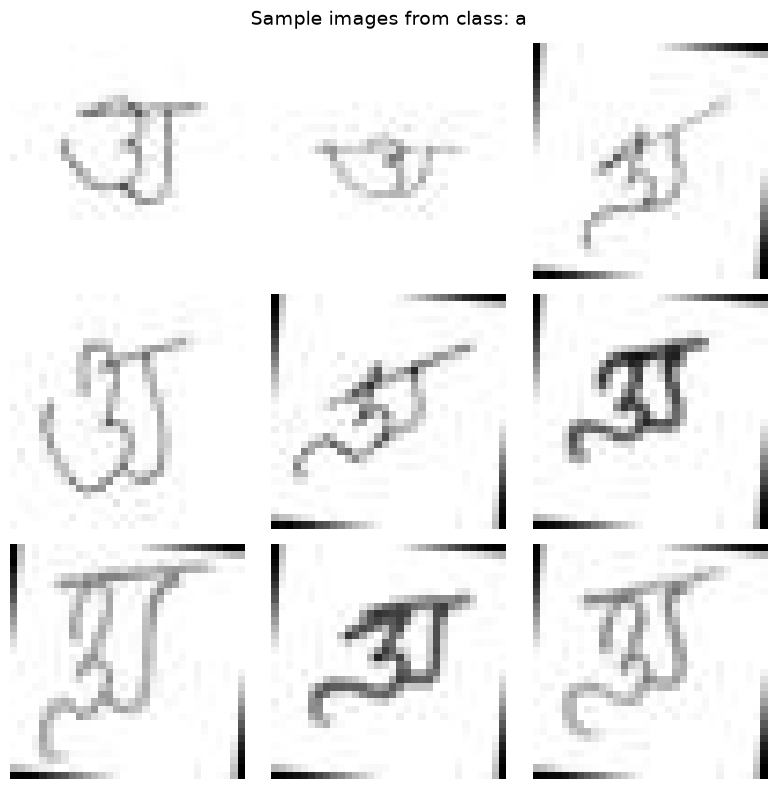

In [17]:
# Display a small grid of images from one character class.
# Looking at multiple samples helps us see how much variation
# exists within the same class.

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for ax, image_path in zip(axes.ravel(), sample_images[:9]):

    # Open the image using PIL (Python Imaging Library).
    image = Image.open(image_path)

    # Display the image.
    ax.imshow(image)

    # Remove axis numbers because they are not useful for
    # simply inspecting the character.
    ax.axis("off")

# Add the class name to the overall figure.
fig.suptitle(f"Sample images from class: {sample_class.name}", fontsize=14)

plt.tight_layout()
plt.show()

## Inspecting Image Dimensions and Color Channels

A CNN needs images in a consistent numerical format.

We will check:
- Image width and height
- Whether images are grayscale or RGB
- Whether all images have the same dimensions

This helps us decide how the images should be prepared before entering the CNN.

In [18]:
# Inspect the dimensions and color mode of a few sample images.
# PIL gives us:
# - image.size -> (width, height)
# - image.mode -> how pixel information is stored
#
# Common modes:
#   "L"  = grayscale (one channel)
#   "RGB" = color (three channels)

for image_path in sample_images[:10]:

    image = Image.open(image_path)

    print(
        f"{image_path.name}: "
        f"size={image.size}, "
        f"mode={image.mode}"
    )

1.jpg: size=(32, 32), mode=RGB
10.jpg: size=(32, 32), mode=RGB
100.jpg: size=(32, 32), mode=RGB
101.jpg: size=(32, 32), mode=RGB
102.jpg: size=(32, 32), mode=RGB
103.jpg: size=(32, 32), mode=RGB
104.jpg: size=(32, 32), mode=RGB
105.jpg: size=(32, 32), mode=RGB
106.jpg: size=(32, 32), mode=RGB
107.jpg: size=(32, 32), mode=RGB


## Checking Dataset Consistency

We have inspected a few images manually.

Now we will check the entire dataset programmatically.

We want to find out:

- Do all images have the same width and height?
- Are all images grayscale or are there multiple formats?
- Are there any unusual images?

Checking all images helps us catch problems that we would not notice by looking at only a few samples.

In [19]:
# Store the different image sizes and color modes we find.
# A "set" keeps only unique values, so we can quickly see
# whether the dataset contains multiple formats.

image_sizes = set()
image_modes = set()

# Keep track of any images that cannot be opened.
# This helps us detect corrupted or invalid image files.
corrupted_images = []

# Check both Training and Testing folders.
for split_path in [training_path, testing_path]:

    # Go through every character/class folder.
    for class_folder in split_path.iterdir():

        if not class_folder.is_dir():
            continue

        # Check every image inside the class folder.
        for image_path in class_folder.iterdir():

            if not image_path.is_file():
                continue

            if image_path.suffix.lower() not in image_extensions:
                continue

            try:
                # Open the image and read its basic properties.
                with Image.open(image_path) as image:
                    image_sizes.add(image.size)
                    image_modes.add(image.mode)

            except Exception:
                # If PIL cannot open an image, record its path.
                corrupted_images.append(image_path)

print("Unique image sizes:", image_sizes)
print("Unique image modes:", image_modes)
print("Corrupted images:", len(corrupted_images))

Unique image sizes: {(32, 32)}
Unique image modes: {'RGB'}
Corrupted images: 0


## 8. Class Distribution

A classification dataset should be checked for class imbalance.

If one character had thousands of examples while another had only a few,
the model could become biased toward the classes with more training data.

We will count the images in every class for:
- Training
- Testing

In [20]:
# Count how many images belong to each character class.
# The folder name is the class label, so we count the images
# inside each class folder.

def count_images_in_classes(split_path):
    counts = {}

    for class_folder in sorted(split_path.iterdir()):
        if not class_folder.is_dir():
            continue

        count = sum(
            1
            for file in class_folder.iterdir()
            if file.is_file()
            and file.suffix.lower() in image_extensions
        )

        counts[class_folder.name] = count

    return counts


# Count images separately for Training and Testing.
training_counts = count_images_in_classes(training_path)
testing_counts = count_images_in_classes(testing_path)

print("Training:")
print(training_counts)

print("\nTesting:")
print(testing_counts)

Training:
{'a': 420, 'aa': 420, 'ah': 420, 'ai': 420, 'am': 420, 'au': 420, 'ba': 420, 'bha': 420, 'ca': 420, 'cha': 420, 'da': 420, 'de': 420, 'dha': 420, 'dhe': 420, 'e': 420, 'ga': 420, 'gha': 420, 'gya': 420, 'ha': 420, 'i': 420, 'ja': 420, 'jha': 420, 'ka': 420, 'kha': 420, 'la': 420, 'ma': 420, 'na': 420, 'naa': 420, 'nya': 420, 'o': 420, 'pa': 420, 'pha': 420, 'ra': 420, 'ria': 420, 'sa': 420, 'sha': 420, 'shaa': 420, 'shya': 420, 'ta': 420, 'tha': 420, 'thya': 420, 'tya': 420, 'u': 420, 'va': 420, 'ya': 420, 'yan': 420}

Testing:
{'a': 180, 'aa': 180, 'ah': 180, 'ai': 180, 'am': 180, 'au': 180, 'ba': 180, 'bha': 180, 'ca': 180, 'cha': 180, 'da': 180, 'de': 180, 'dha': 180, 'dhe': 180, 'e': 180, 'ga': 180, 'gha': 180, 'gya': 180, 'ha': 180, 'i': 180, 'ja': 180, 'jha': 180, 'ka': 180, 'kha': 180, 'la': 180, 'ma': 180, 'na': 180, 'naa': 180, 'nya': 180, 'o': 180, 'pa': 180, 'pha': 180, 'ra': 180, 'ria': 180, 'sa': 180, 'sha': 180, 'shaa': 180, 'shya': 180, 'ta': 180, 'tha': 180, '

## 9. Class Distribution Visualization

We have confirmed that every class contains the same number of images.

A bar chart gives us a quick visual confirmation and will also make
imbalanced datasets easier to recognize in future projects.

In [21]:
# Convert our class-count dictionaries into a DataFrame.
# A DataFrame makes the data easier to analyze and visualize.

distribution_df = pd.DataFrame({
    "Class": list(training_counts.keys()),
    "Training": list(training_counts.values()),
    "Testing": [
        testing_counts[class_name]
        for class_name in training_counts.keys()
    ]
})

# Display the first few rows so we can verify the table.
distribution_df.head()

,Class,Training,Testing
0,a,420,180
1,aa,420,180
2,ah,420,180
3,ai,420,180
4,am,420,180


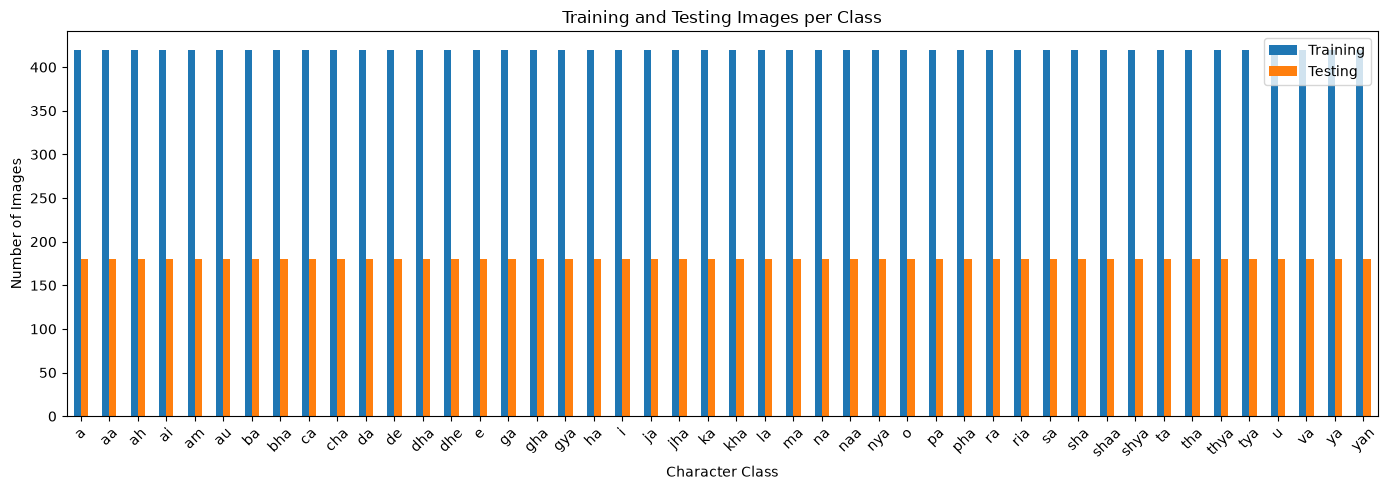

In [22]:
# Plot the number of images in each class.
# Since all classes have the same count, we expect the bars
# to have the same height.

distribution_df.set_index("Class")[["Training", "Testing"]].plot(
    kind="bar",
    figsize=(14, 5)
)

plt.title("Training and Testing Images per Class")
plt.xlabel("Character Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 10. Visual Overview of All Classes

We have 46 different character classes.

Instead of inspecting one class at a time, we will display
one sample from every class in a single gallery.

This helps us visually check:
- Whether the classes look distinct
- Whether some characters look very similar
- Whether image quality is reasonably consistent

In [23]:
# Count how many images belong to each character class.
# The folder name is the class label, so we count the images
# inside each class folder.

def count_images_in_classes(split_path):
    counts = {}

    for class_folder in sorted(split_path.iterdir()):
        if not class_folder.is_dir():
            continue

        count = sum(
            1
            for file in class_folder.iterdir()
            if file.is_file()
            and file.suffix.lower() in image_extensions
        )

        counts[class_folder.name] = count

    return counts


# Count images separately for Training and Testing.
training_counts = count_images_in_classes(training_path)
testing_counts = count_images_in_classes(testing_path)

print("Training:")
print(training_counts)

print("\nTesting:")
print(testing_counts)

Training:
{'a': 420, 'aa': 420, 'ah': 420, 'ai': 420, 'am': 420, 'au': 420, 'ba': 420, 'bha': 420, 'ca': 420, 'cha': 420, 'da': 420, 'de': 420, 'dha': 420, 'dhe': 420, 'e': 420, 'ga': 420, 'gha': 420, 'gya': 420, 'ha': 420, 'i': 420, 'ja': 420, 'jha': 420, 'ka': 420, 'kha': 420, 'la': 420, 'ma': 420, 'na': 420, 'naa': 420, 'nya': 420, 'o': 420, 'pa': 420, 'pha': 420, 'ra': 420, 'ria': 420, 'sa': 420, 'sha': 420, 'shaa': 420, 'shya': 420, 'ta': 420, 'tha': 420, 'thya': 420, 'tya': 420, 'u': 420, 'va': 420, 'ya': 420, 'yan': 420}

Testing:
{'a': 180, 'aa': 180, 'ah': 180, 'ai': 180, 'am': 180, 'au': 180, 'ba': 180, 'bha': 180, 'ca': 180, 'cha': 180, 'da': 180, 'de': 180, 'dha': 180, 'dhe': 180, 'e': 180, 'ga': 180, 'gha': 180, 'gya': 180, 'ha': 180, 'i': 180, 'ja': 180, 'jha': 180, 'ka': 180, 'kha': 180, 'la': 180, 'ma': 180, 'na': 180, 'naa': 180, 'nya': 180, 'o': 180, 'pa': 180, 'pha': 180, 'ra': 180, 'ria': 180, 'sa': 180, 'sha': 180, 'shaa': 180, 'shya': 180, 'ta': 180, 'tha': 180, '

NameError: name 'class_samples' is not defined

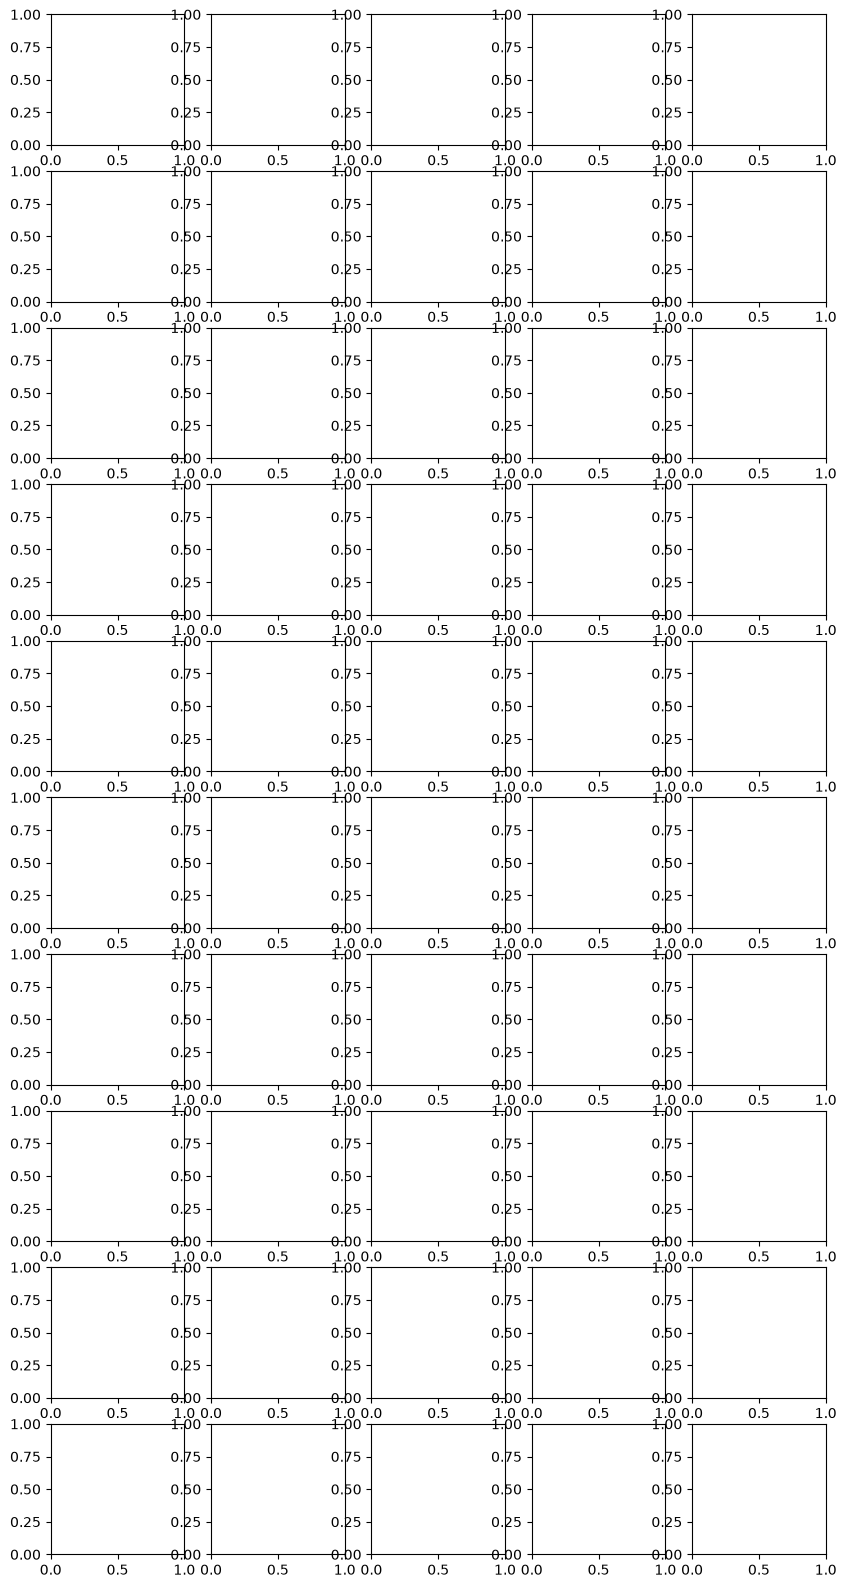

In [24]:
# Create a 5-column gallery.
# 46 classes require 10 rows to display all samples.

fig, axes = plt.subplots(10, 5, figsize=(10, 20))

for ax, (class_name, image_path) in zip(axes.ravel(), class_samples):

    # Open the image and display it.
    image = Image.open(image_path)

    ax.imshow(image)

    # Show the class name above each image.
    ax.set_title(class_name)

    # Hide axes because we only care about the character.
    ax.axis("off")


# Hide any unused subplot cells.
for ax in axes.ravel()[len(class_samples):]:
    ax.axis("off")

plt.suptitle("One Sample from Each LipiLens Character Class", fontsize=16)

plt.tight_layout()
plt.show()

In [25]:
# Create one representative sample image for every character class.
# Each class has its own folder, so the folder name acts as the label.

class_samples = []

for class_folder in sorted(training_classes, key=lambda x: x.name):

    # Find image files inside this character's folder.
    images = [
        file for file in class_folder.iterdir()
        if file.is_file()
        and file.suffix.lower() in image_extensions
    ]

    # Save the class name together with one image path.
    if images:
        class_samples.append((class_folder.name, images[0]))

print("Number of classes with a sample:", len(class_samples))

Number of classes with a sample: 46


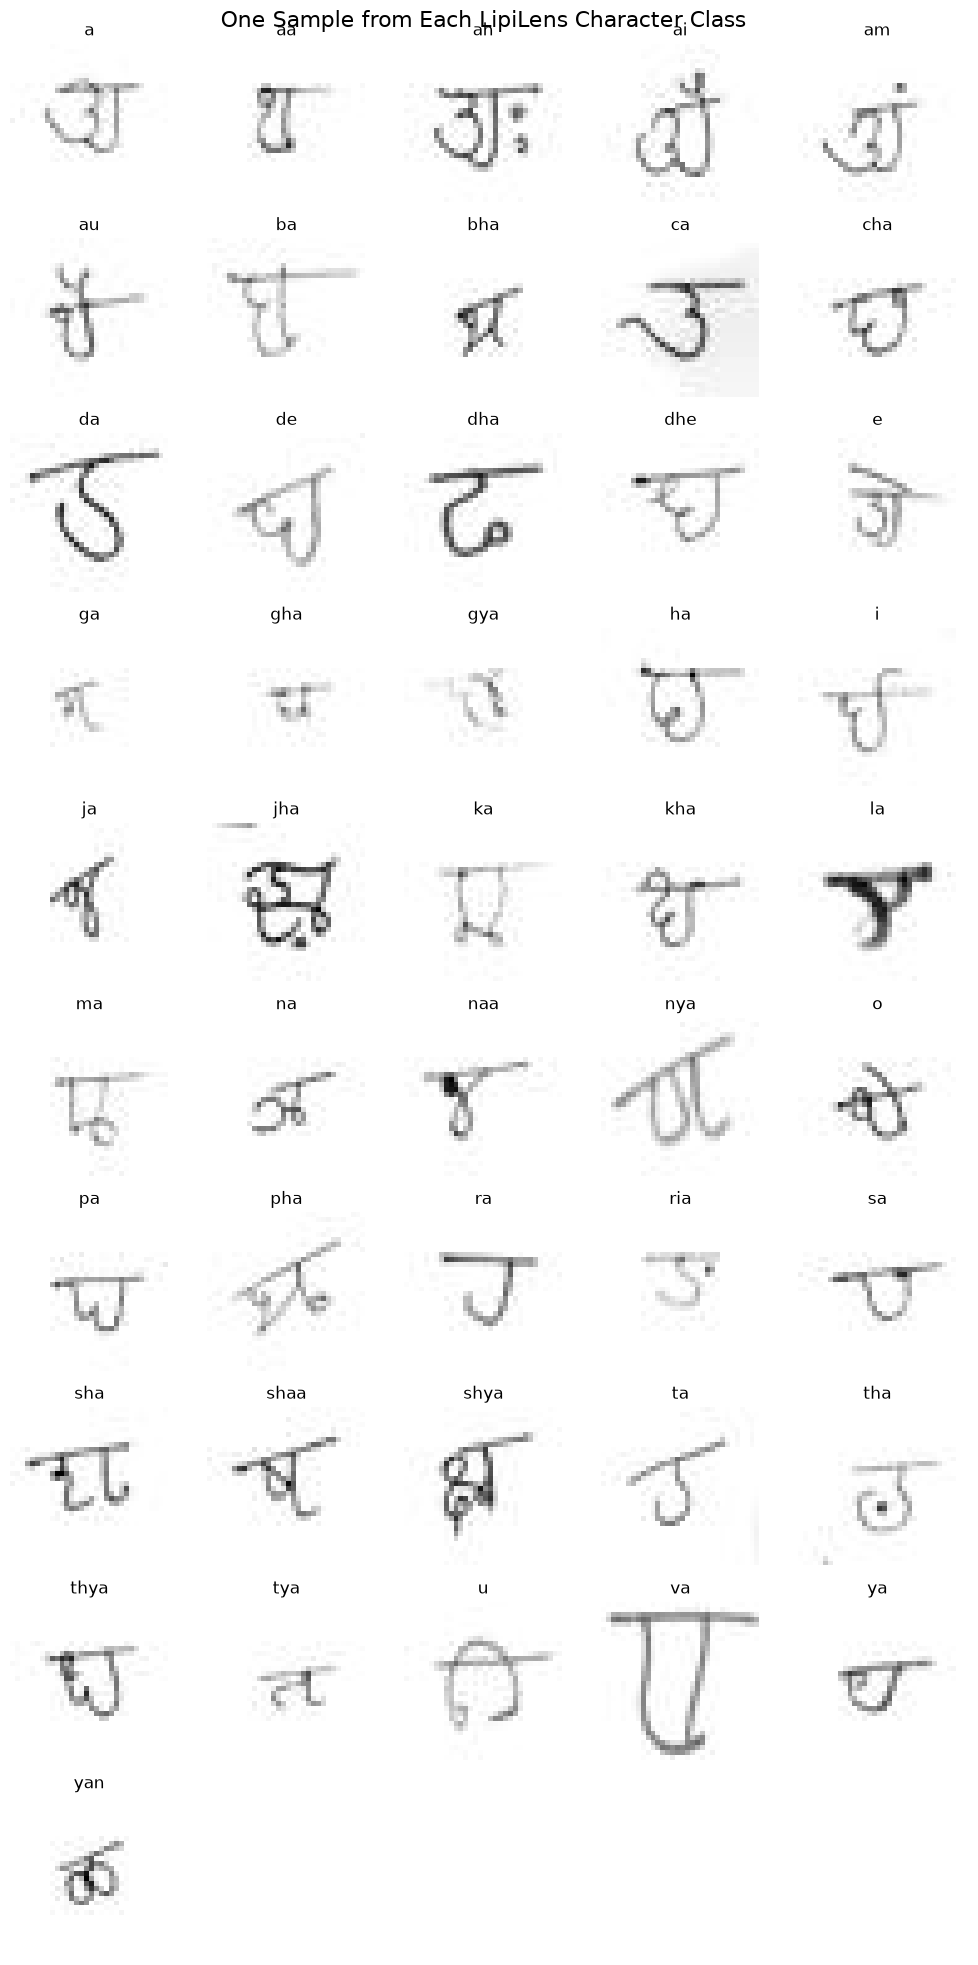

In [26]:
# Create a grid with 5 columns.
# We need 10 rows because there are 46 character classes.

fig, axes = plt.subplots(10, 5, figsize=(10, 20))

for ax, (class_name, image_path) in zip(axes.ravel(), class_samples):

    # Open the selected image.
    image = Image.open(image_path)

    # Display the character.
    ax.imshow(image)

    # Display the class name above the image.
    ax.set_title(class_name)

    # Hide the x/y axes because they are not useful here.
    ax.axis("off")


# Turn off any unused cells in the grid.
for ax in axes.ravel()[len(class_samples):]:
    ax.axis("off")

plt.suptitle(
    "One Sample from Each LipiLens Character Class",
    fontsize=16
)

plt.tight_layout()
plt.show()

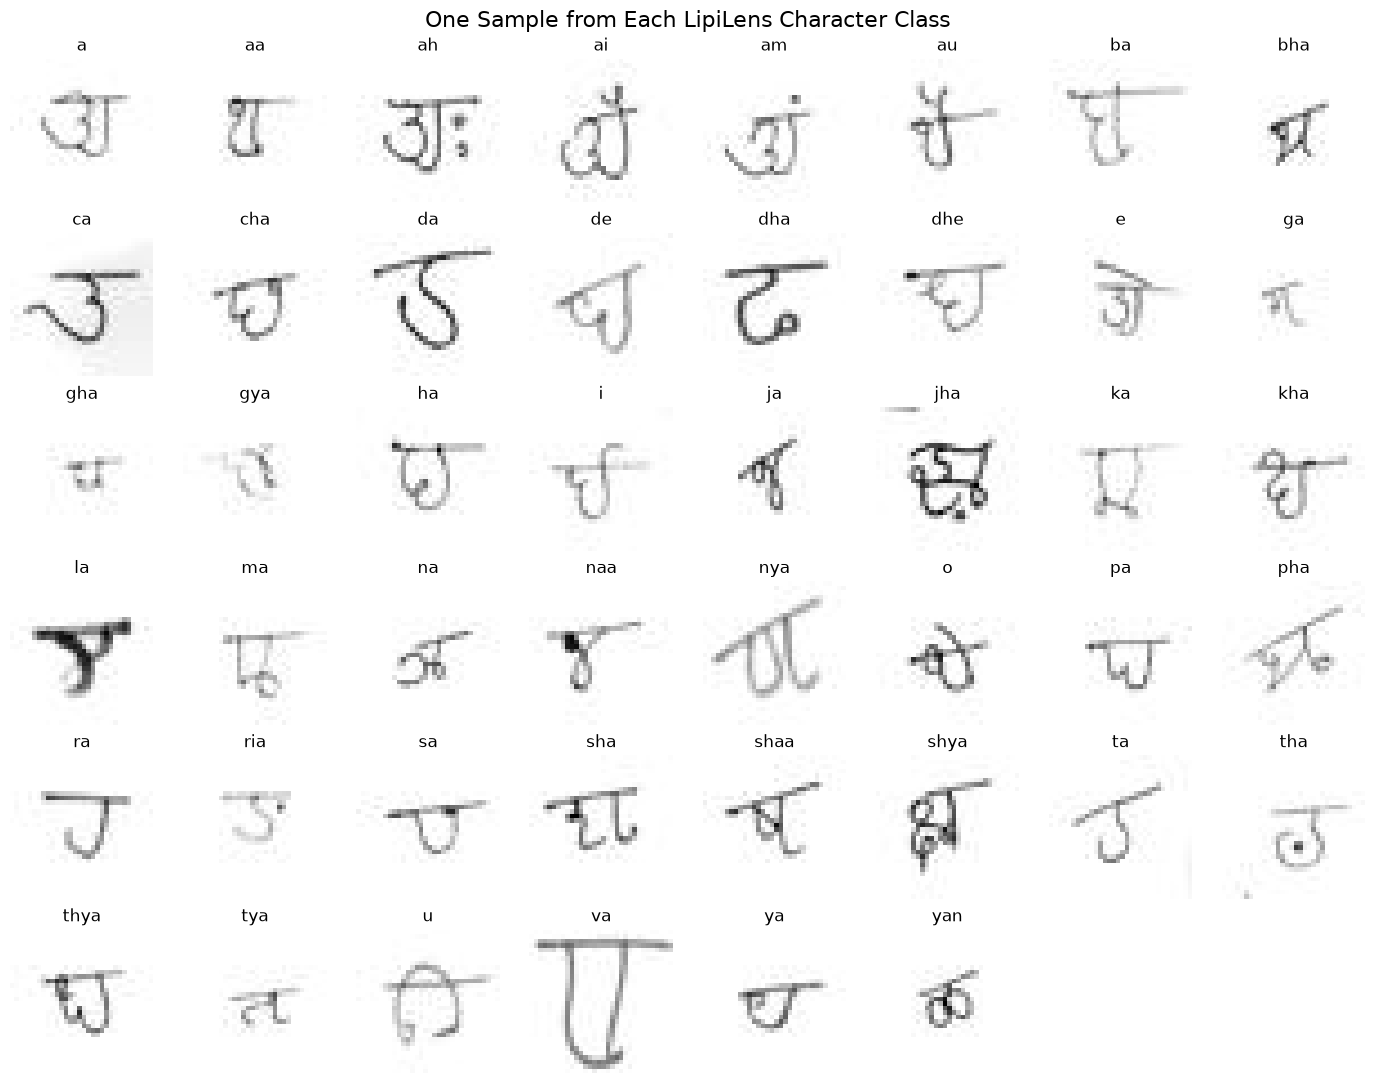

In [27]:
# Use 8 columns and 6 rows so each 32x32 character gets
# a little more visual space.

fig, axes = plt.subplots(6, 8, figsize=(14, 11))

for ax, (class_name, image_path) in zip(axes.ravel(), class_samples):

    # Open and display the representative image.
    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")


# Hide the two unused cells.
for ax in axes.ravel()[len(class_samples):]:
    ax.axis("off")

plt.suptitle(
    "One Sample from Each LipiLens Character Class",
    fontsize=16
)

plt.tight_layout()
plt.show()

## 11. Exploring the Dataset Metadata

The dataset folders tell us which images belong to each class.

The metadata file may contain additional information about those classes
or individual images.

We will inspect its structure before deciding whether we need it
in the training pipeline.

In [28]:
# Point to the metadata file in the project root.
# Our notebook is inside "notebooks/", so we move one level up.

metadata_path = project_root / "metadata.csv"

print("Metadata path:", metadata_path)
print("File exists:", metadata_path.exists())

Metadata path: d:\Projects\Lipilens\metadata.csv
File exists: True


In [29]:
# Load the CSV file into a Pandas DataFrame.
# A DataFrame lets us inspect rows, columns, and data types easily.

metadata = pd.read_csv(metadata_path)

print("Rows:", len(metadata))
print("Columns:", len(metadata.columns))

print("\nColumn names:")
print(list(metadata.columns))

Rows: 27600
Columns: 3

Column names:
['file_name', 'character', 'split']


In [30]:
# Display the first few rows of the metadata.
# This gives us a quick idea of what each column represents.

metadata.head(10)

,file_name,character,split
0,Training\a\1.jpg,a,Training
1,Training\a\10.jpg,a,Training
2,Training\a\100.jpg,a,Training
3,Training\a\101.jpg,a,Training
4,Training\a\102.jpg,a,Training
5,Training\a\103.jpg,a,Training
6,Training\a\104.jpg,a,Training
7,Training\a\105.jpg,a,Training
8,Training\a\106.jpg,a,Training
9,Training\a\107.jpg,a,Training


In [31]:
# Check the type of information stored in each column.
# This helps us understand whether columns contain text,
# numbers, labels, or other types of data.

metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 27600 entries, 0 to 27599
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   file_name  27600 non-null  str  
 1   character  27600 non-null  str  
 2   split      27600 non-null  str  
dtypes: str(3)
memory usage: 647.0 KB


In [32]:
# Display a few rows from the metadata file.
# We want to see the exact format of:
# - file_name
# - character
# - split
#
# This will help us understand how the CSV maps to the actual
# folder structure of our dataset.

metadata.head(10)

,file_name,character,split
0,Training\a\1.jpg,a,Training
1,Training\a\10.jpg,a,Training
2,Training\a\100.jpg,a,Training
3,Training\a\101.jpg,a,Training
4,Training\a\102.jpg,a,Training
5,Training\a\103.jpg,a,Training
6,Training\a\104.jpg,a,Training
7,Training\a\105.jpg,a,Training
8,Training\a\106.jpg,a,Training
9,Training\a\107.jpg,a,Training


In [33]:
# Count how many unique characters are listed in the metadata.
# This should match the 46 class folders we found earlier.

print("Unique characters:", metadata["character"].nunique())

# Show the different dataset splits recorded in the CSV.
# We expect to see Training and Testing.

print("\nSplits:")
print(metadata["split"].value_counts())

Unique characters: 46

Splits:
split
Training    19320
Testing      8280
Name: count, dtype: int64


In [34]:
# Check whether the metadata has exactly one row per image.
# If file_name values are duplicated, the same image may appear
# more than once in the metadata.

duplicate_files = metadata["file_name"].duplicated().sum()

print("Duplicate file names:", duplicate_files)

Duplicate file names: 0


## 12. Verifying Metadata Against the Dataset

The CSV and folder structure both describe the dataset.

Before using either one for training, we should make sure they agree.

For each metadata row, we will check:

- Does the referenced image actually exist?
- Does its Training/Testing split match its folder?
- Does its character label match the class folder?

This prevents silent labeling mistakes from entering the ML pipeline.

In [35]:
# Check whether every metadata entry points to a real image
# in the expected Training/Testing and character folder.

missing_files = []
wrong_split = []
wrong_character = []

for _, row in metadata.iterrows():

    # Build the expected path from the metadata.
    # Example:
    # dataset/Training/a/1.jpg
    expected_path = (
        dataset_path
        / row["split"]
        / row["character"]
        / row["file_name"]
    )

    # Check whether the image actually exists.
    if not expected_path.exists():
        missing_files.append(expected_path)

print("Missing files:", len(missing_files))

Missing files: 27600


In [36]:
# Verify that the metadata's character and split information
# agree with the actual folder structure.

for _, row in metadata.iterrows():

    expected_path = (
        dataset_path
        / row["split"]
        / row["character"]
        / row["file_name"]
    )

    # The parent folder immediately contains the character label.
    actual_character = expected_path.parent.name

    # The folder above that contains Training or Testing.
    actual_split = expected_path.parent.parent.name

    if actual_character != row["character"]:
        wrong_character.append((row["file_name"], row["character"], actual_character))

    if actual_split != row["split"]:
        wrong_split.append((row["file_name"], row["split"], actual_split))


print("Wrong character labels:", len(wrong_character))
print("Wrong split labels:", len(wrong_split))

Wrong character labels: 0
Wrong split labels: 0


## Conclusion

The Modi Matra dataset contains:

- 46 character classes
- 19,320 training images
- 8,280 testing images
- 27,600 images in total
- 420 training images per class
- 180 testing images per class
- Images are 32 × 32 RGB
- No corrupted images were detected
- No duplicate filenames were found
- Metadata and folder structure are consistent

The dataset is balanced across all 46 classes.

The next step is to convert these image files into a PyTorch
data pipeline that can feed batches of tensors into a CNN.